Training Score Network...
Epoch    0 | Loss: 0.9587
Epoch  500 | Loss: 0.3041
Epoch 1000 | Loss: 0.2822
Epoch 1500 | Loss: 0.3122
Epoch 2000 | Loss: 0.2809
Epoch 2500 | Loss: 0.2850
Epoch 2999 | Loss: 0.2936

Simulating Backward Process...


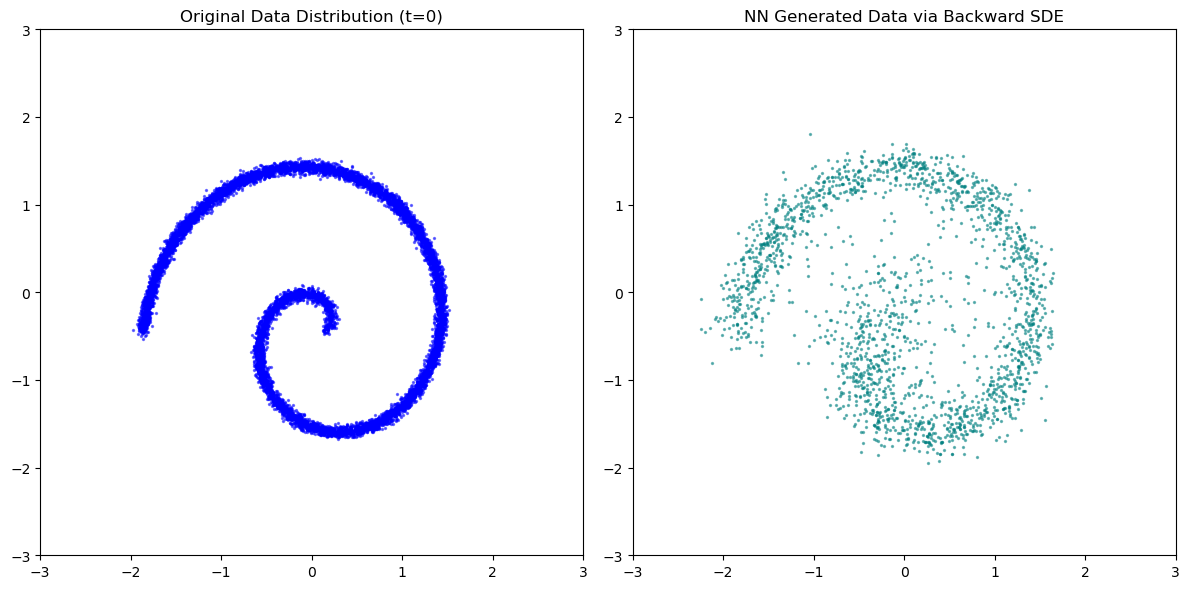

<Figure size 640x480 with 0 Axes>

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SDE Parameters (From your equations)
# ==========================================
lmbda = 1.0   # Drift parameter (\lambda)
D = 0.5       # Diffusion parameter (Variance is 2D)
T = 2.0       # Total forward time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 2. Dataset: The 2D Spiral
# ==========================================
def get_spiral_data(n_samples=10000):
    """Generates a 2D spiral with some noise."""
    theta = np.sqrt(np.random.rand(n_samples)) * 3 * np.pi
    r = theta
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    data = np.stack([x, y], axis=1)
    data += np.random.randn(*data.shape) * 0.15  # Add a little noise
    
    # Normalize the data to zero mean and unit variance for stable training
    data = (data - data.mean(axis=0)) / data.std(axis=0)
    return torch.tensor(data, dtype=torch.float32)

# ==========================================
# 3. The Score Network s_\theta(x, t)
# ==========================================
class ScoreNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # A simple Multi-Layer Perceptron (MLP). 
        # For complex data we'd use U-Nets, but for 2D points an MLP is perfect.
        self.net = nn.Sequential(
            nn.Linear(3, 128), # Input: x, y, and time t
            nn.SiLU(),         # Swish activation works very well for score models
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 2)  # Output: 2D Score vector
        )

    def forward(self, x, t):
        # Concatenate 2D spatial coordinates with 1D time coordinate
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

# ==========================================
# 4. Training (Denoising Score Matching)
# ==========================================
print("Training Score Network...")
model = ScoreNetwork().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
dataset = get_spiral_data().to(device)

batch_size = 1024
epochs = 3000

for epoch in range(epochs):
    # a) Sample a random batch of original spiral points (x_0)
    idx = torch.randint(0, dataset.size(0), (batch_size,))
    x_0 = dataset[idx]

    # b) Sample random times t ~ U(0.01, T)
    # We avoid exact 0 because the score approaches infinity as variance -> 0
    t = torch.rand(batch_size, 1, device=device) * (T - 0.01) + 0.01

    # c) Calculate the marginal p(x_t | x_0) using the analytical OU integration
    mean_factor = torch.exp(-lmbda * t)
    var = (D / lmbda) * (1 - torch.exp(-2 * lmbda * t))
    std = torch.sqrt(var)

    # d) Generate noise and create the perturbed data x_t
    z = torch.randn_like(x_0)
    x_t = x_0 * mean_factor + z * std

    # e) The optimal target score for p(x_t | x_0) is analytically known:
    # \nabla_x \log p(x_t | x_0) = -(x_t - \mu_t) / \sigma_t^2 = -z / \sigma_t
    target_score = -z / std

    # f) Predict the score
    predicted_score = model(x_t, t)

    # g) Calculate Loss: We weight the MSE by 'var' to stabilize training near t=0
    # This is a standard trick in diffusion models (variance weighting)
    loss = torch.mean(var * (predicted_score - target_score)**2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:>4} | Loss: {loss.item():.4f}")

# ==========================================
# 5. Backward SDE Simulation (Sampling)
# ==========================================
print("\nSimulating Backward Process...")
model.eval()
n_samples = 2000
N_steps = 1000
dt = T / N_steps

# Step 1: Start from the steady-state Gaussian at time T
# Variance at T:
var_T = (D / lmbda) * (1 - np.exp(-2 * lmbda * T))
x_current = torch.randn(n_samples, 2, device=device) * np.sqrt(var_T)

trajectory = [x_current.detach().cpu().numpy()]

with torch.no_grad():
    # Step 2: Euler-Maruyama integration backwards in time
    for i in range(N_steps):
        t_val = T - i * dt
        t_tensor = torch.full((n_samples, 1), t_val, device=device)
        
        # Get the approximated score from our neural network
        score = model(x_current, t_tensor)
        
        # Anderson's Theorem Backward Drift: [\lambda x + 2D \nabla_x \log p(x,t)]
        backward_drift = lmbda * x_current + 2 * D * score
        
        # Generate random noise for the backward step
        noise = torch.randn_like(x_current) * np.sqrt(2 * D * dt)
        
        # Update position
        x_current = x_current + backward_drift * dt + noise
        
        # Save every 100 steps for plotting
        if i % 100 == 0:
            trajectory.append(x_current.cpu().numpy())

generated_data = x_current.cpu().numpy()
original_data = dataset.cpu().numpy()

# ==========================================
# 6. Visualization
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(original_data[:, 0], original_data[:, 1], s=2, color='blue', alpha=0.5)
axes[0].set_title("Original Data Distribution (t=0)")
axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)

axes[1].scatter(generated_data[:, 0], generated_data[:, 1], s=2, color='teal', alpha=0.5)
axes[1].set_title("NN Generated Data via Backward SDE")
axes[1].set_xlim(-3, 3)
axes[1].set_ylim(-3, 3)

plt.tight_layout()
plt.show()
plt.savefig("Spiral_naive.pdf",bbox_inches="tight")

Training Advanced Score Network...
Epoch    0 | Loss: 1.01859
Epoch 1000 | Loss: 0.30143
Epoch 2000 | Loss: 0.29402
Epoch 3000 | Loss: 0.31052
Epoch 4000 | Loss: 0.28715
Epoch 4999 | Loss: 0.29740

Simulating Backward Process...


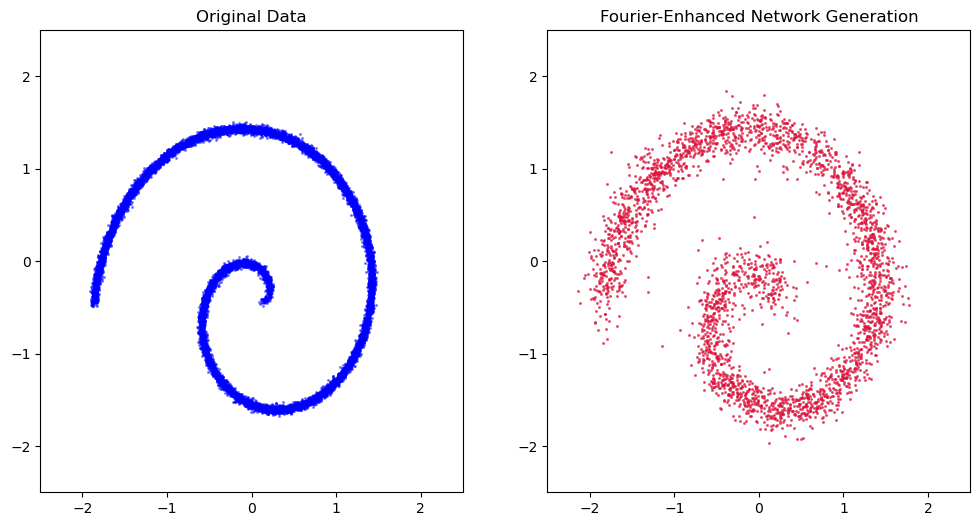

<Figure size 640x480 with 0 Axes>

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# SDE Parameters
lmbda = 1.0   
D = 0.5       
T = 2.0       
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Dataset Generation
def get_spiral_data(n_samples=15000):
    theta = np.sqrt(np.random.rand(n_samples)) * 3 * np.pi
    r = theta
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    data = np.stack([x, y], axis=1)
    data += np.random.randn(*data.shape) * 0.1  # Cleaner original data
    data = (data - data.mean(axis=0)) / data.std(axis=0)
    return torch.tensor(data, dtype=torch.float32)

# 2. Fourier Feature Projection for Coordinates and Time
class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim, scale=16.0):
        super().__init__()
        # Fixed random frequencies
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
        
    def forward(self, x):
        # x shape: [batch, 1] or [batch, 2]
        x_proj = x @ self.W.unsqueeze(0) # [batch, embed_dim // 2]
        return torch.cat([torch.sin(2 * np.pi * x_proj), torch.cos(2 * np.pi * x_proj)], dim=-1)

# 3. Upgraded Score Architecture with Time Embedding & ResBlocks
class DenseResBlock(nn.Module):
    def __init__(self, dim, temb_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim),
            nn.SiLU(),
            nn.Linear(dim, dim)
        )
        # Projects time embedding into the feature dimension
        self.temb_proj = nn.Linear(temb_dim, dim)
        self.act = nn.SiLU()
        
    def forward(self, x, temb):
        # Scale and Shift feature map based on the time step
        h = self.mlp(x) + self.temb_proj(self.act(temb))
        return x + h # Residual Connection preserves fine gradients

class AdvancedScoreNetwork(nn.Module):
    def __init__(self, hidden_dim=256):
        super().__init__()
        # High-frequency projections
        self.coord_embed = GaussianFourierProjection(embed_dim=64, scale=10.0)
        self.time_embed = nn.Sequential(
            GaussianFourierProjection(embed_dim=64, scale=10.0),
            nn.Linear(64, hidden_dim),
            nn.SiLU()
        )
        
        # Spatial layers
        self.input_layer = nn.Linear(64 * 2, hidden_dim) # 2D coords projected
        
        self.res1 = DenseResBlock(hidden_dim, hidden_dim)
        self.res2 = DenseResBlock(hidden_dim, hidden_dim)
        self.res3 = DenseResBlock(hidden_dim, hidden_dim)
        
        self.output_layer = nn.Linear(hidden_dim, 2)

    def forward(self, x, t):
        # Embed time
        temb = self.time_embed(t)
        
        # Embed X and Y separately and concatenate
        x_emb = self.coord_embed(x[:, 0:1])
        y_emb = self.coord_embed(x[:, 1:2])
        coord_emb = torch.cat([x_emb, y_emb], dim=-1)
        
        # Pass through Residual Bottleneck
        h = self.input_layer(coord_emb)
        h = self.res1(h, temb)
        h = self.res2(h, temb)
        h = self.res3(h, temb)
        
        return self.output_layer(h)

# 4. Training
print("Training Advanced Score Network...")
model = AdvancedScoreNetwork().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
dataset = get_spiral_data().to(device)

batch_size = 1024
epochs = 5000

for epoch in range(epochs):
    idx = torch.randint(0, dataset.size(0), (batch_size,))
    x_0 = dataset[idx]

    # Sample t uniformly, avoiding the boundary 0
    t = torch.rand(batch_size, 1, device=device) * (T - 0.01) + 0.01

    var = (D / lmbda) * (1 - torch.exp(-2 * lmbda * t))
    std = torch.sqrt(var)
    
    z = torch.randn_like(x_0)
    x_t = x_0 * torch.exp(-lmbda * t) + z * std
    target_score = -z / std

    predicted_score = model(x_t, t)
    
    # Standard loss weighting
    loss = torch.mean(var * (predicted_score - target_score)**2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:>4} | Loss: {loss.item():.5f}")

# 5. Backward SDE Simulation
print("\nSimulating Backward Process...")
model.eval()
n_samples = 3000
N_steps = 2000
dt = T / N_steps

# Start from pure noise at T
var_T = (D / lmbda) * (1 - np.exp(-2 * lmbda * T))
x_current = torch.randn(n_samples, 2, device=device) * np.sqrt(var_T)

with torch.no_grad():
    for i in range(N_steps):
        t_val = T - i * dt
        
        # CRITICAL: Stop the simulation just before t hits 0 to avoid exploding scores
        if t_val < 0.005: 
            break
            
        t_tensor = torch.full((n_samples, 1), t_val, device=device)
        score = model(x_current, t_tensor)
        
        backward_drift = lmbda * x_current + 2 * D * score
        noise = torch.randn_like(x_current) * np.sqrt(2 * D * dt)
        
        x_current = x_current + backward_drift * dt + noise

generated_data = x_current.cpu().numpy()
original_data = dataset.cpu().numpy()

# 6. Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].scatter(original_data[:, 0], original_data[:, 1], s=1.5, color='blue', alpha=0.4)
axes[0].set_title("Original Data")
axes[0].set_xlim(-2.5, 2.5); axes[0].set_ylim(-2.5, 2.5)

axes[1].scatter(generated_data[:, 0], generated_data[:, 1], s=1.5, color='crimson', alpha=0.6)
axes[1].set_title("Fourier-Enhanced Network Generation")
axes[1].set_xlim(-2.5, 2.5); axes[1].set_ylim(-2.5, 2.5)
plt.show()
plt.savefig("Spiral_Fourier.pdf",bbox_inches="tight")

Training Advanced Score Network...
Epoch    0 | Loss: 1.06551
Epoch 1000 | Loss: 0.32588
Epoch 2000 | Loss: 0.32356
Epoch 3000 | Loss: 0.30154
Epoch 4000 | Loss: 0.27549
Epoch 4999 | Loss: 0.27772

Simulating Backward Process via Predictor-Corrector Sampler...


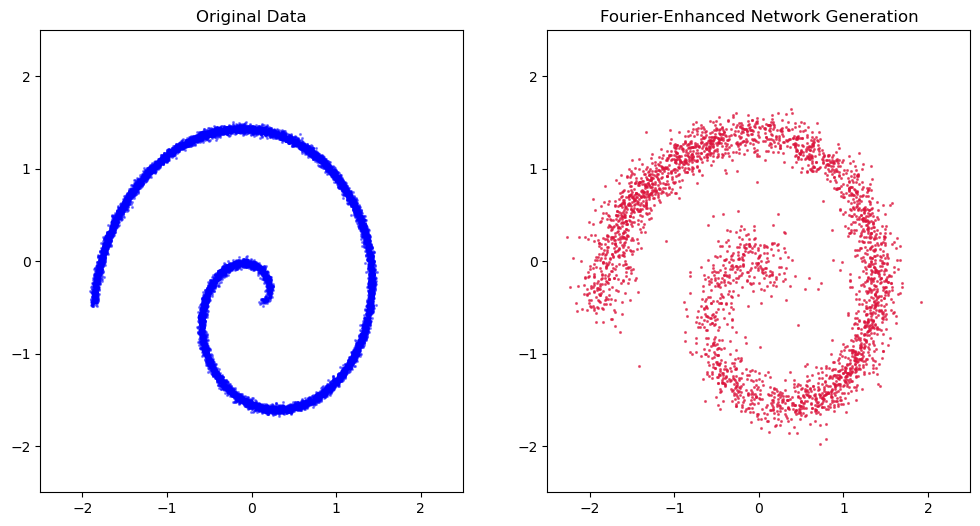

<Figure size 640x480 with 0 Axes>

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# SDE Parameters
lmbda = 1.0   
D = 0.5       
T = 2.0       
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Dataset Generation
def get_spiral_data(n_samples=15000):
    theta = np.sqrt(np.random.rand(n_samples)) * 3 * np.pi
    r = theta
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    data = np.stack([x, y], axis=1)
    data += np.random.randn(*data.shape) * 0.1  # Cleaner original data
    data = (data - data.mean(axis=0)) / data.std(axis=0)
    return torch.tensor(data, dtype=torch.float32)

# 2. Fourier Feature Projection for Coordinates and Time
class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim, scale=16.0):
        super().__init__()
        # Fixed random frequencies
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
        
    def forward(self, x):
        # x shape: [batch, 1] or [batch, 2]
        x_proj = x @ self.W.unsqueeze(0) # [batch, embed_dim // 2]
        return torch.cat([torch.sin(2 * np.pi * x_proj), torch.cos(2 * np.pi * x_proj)], dim=-1)

# 3. Upgraded Score Architecture with Time Embedding & ResBlocks
class DenseResBlock(nn.Module):
    def __init__(self, dim, temb_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim),
            nn.SiLU(),
            nn.Linear(dim, dim)
        )
        # Projects time embedding into the feature dimension
        self.temb_proj = nn.Linear(temb_dim, dim)
        self.act = nn.SiLU()
        
    def forward(self, x, temb):
        # Scale and Shift feature map based on the time step
        h = self.mlp(x) + self.temb_proj(self.act(temb))
        return x + h # Residual Connection preserves fine gradients

class AdvancedScoreNetwork(nn.Module):
    def __init__(self, hidden_dim=256):
        super().__init__()
        # High-frequency projections
        self.coord_embed = GaussianFourierProjection(embed_dim=64, scale=10.0)
        self.time_embed = nn.Sequential(
            GaussianFourierProjection(embed_dim=64, scale=10.0),
            nn.Linear(64, hidden_dim),
            nn.SiLU()
        )
        
        # Spatial layers
        self.input_layer = nn.Linear(64 * 2, hidden_dim) # 2D coords projected
        
        self.res1 = DenseResBlock(hidden_dim, hidden_dim)
        self.res2 = DenseResBlock(hidden_dim, hidden_dim)
        self.res3 = DenseResBlock(hidden_dim, hidden_dim)
        
        self.output_layer = nn.Linear(hidden_dim, 2)

    def forward(self, x, t):
        # Embed time
        temb = self.time_embed(t)
        
        # Embed X and Y separately and concatenate
        x_emb = self.coord_embed(x[:, 0:1])
        y_emb = self.coord_embed(x[:, 1:2])
        coord_emb = torch.cat([x_emb, y_emb], dim=-1)
        
        # Pass through Residual Bottleneck
        h = self.input_layer(coord_emb)
        h = self.res1(h, temb)
        h = self.res2(h, temb)
        h = self.res3(h, temb)
        
        return self.output_layer(h)

# 4. Training
print("Training Advanced Score Network...")
model = AdvancedScoreNetwork().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
dataset = get_spiral_data().to(device)

batch_size = 1024
epochs = 5000

for epoch in range(epochs):
    idx = torch.randint(0, dataset.size(0), (batch_size,))
    x_0 = dataset[idx]

    # Sample t uniformly, avoiding the boundary 0
    t = torch.rand(batch_size, 1, device=device) * (T - 0.01) + 0.01

    var = (D / lmbda) * (1 - torch.exp(-2 * lmbda * t))
    std = torch.sqrt(var)
    
    z = torch.randn_like(x_0)
    x_t = x_0 * torch.exp(-lmbda * t) + z * std
    target_score = -z / std

    predicted_score = model(x_t, t)
    
    # Standard loss weighting
    loss = torch.mean(var * (predicted_score - target_score)**2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:>4} | Loss: {loss.item():.5f}")

# =========================================================================
# Upgraded Section 5: Predictor-Corrector (PC) Backward Sampling
# =========================================================================
print("\nSimulating Backward Process via Predictor-Corrector Sampler...")
model.eval()
n_samples = 3000
N_steps = 1000  # We can even use fewer total steps because of the corrector!
dt = T / N_steps

# Corrector Hyperparameters
n_corrector_steps = 3   # Number of Langevin steps per SDE step
snr = 0.15              # Signal-to-Noise Ratio controlling corrector step size

# Start from pure noise at T
var_T = (D / lmbda) * (1 - np.exp(-2 * lmbda * T))
x_current = torch.randn(n_samples, 2, device=device) * np.sqrt(var_T)

with torch.no_grad():
    for i in range(N_steps):
        t_val = T - i * dt
        if t_val < 0.005: 
            break
            
        t_tensor = torch.full((n_samples, 1), t_val, device=device)
        
        # -------------------------------------------------------------
        # PHASE 1: Corrector Step (Langevin Dynamics at fixed time t)
        # -------------------------------------------------------------
        for _ in range(n_corrector_steps):
            score = model(x_current, t_tensor)
            
            # Estimate an adaptive step size based on the magnitude of the score
            noise = torch.randn_like(x_current)
            grad_norm = torch.norm(score, dim=-1, keepdim=True).mean()
            noise_norm = torch.norm(noise, dim=-1, keepdim=True).mean()
            step_size = 2 * (snr * noise_norm / grad_norm) ** 2
            
            # Langevin update: move towards higher density + inject fresh scaled noise
            x_current = x_current + step_size * score + torch.sqrt(2 * step_size) * noise

        # -------------------------------------------------------------
        # PHASE 2: Predictor Step (Standard Backward SDE Step to t - dt)
        # -------------------------------------------------------------
        score = model(x_current, t_tensor)
        backward_drift = lmbda * x_current + 2 * D * score
        noise = torch.randn_like(x_current) * np.sqrt(2 * D * dt)
        
        x_current = x_current + backward_drift * dt + noise

generated_data = x_current.cpu().numpy()

# 6. Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].scatter(original_data[:, 0], original_data[:, 1], s=1.5, color='blue', alpha=0.4)
axes[0].set_title("Original Data")
axes[0].set_xlim(-2.5, 2.5); axes[0].set_ylim(-2.5, 2.5)

axes[1].scatter(generated_data[:, 0], generated_data[:, 1], s=1.5, color='crimson', alpha=0.6)
axes[1].set_title("Fourier-Enhanced Network Generation")
axes[1].set_xlim(-2.5, 2.5); axes[1].set_ylim(-2.5, 2.5)
plt.show()
plt.savefig("MCMC_spiral.pdf", bbox_inches="tight")